### HOMEWORK - 1

Choose some grayscale images (NOT CAMERAMAN or the ones used during the lessons) and test them on
1. denoise
2. deblur
3. super resolution
4. CT image reconstruction

For each of the previous tasks:
- create a test problem, changing both the parameters of the operator and the noise level
- solve with a model-based regularization method by using the regularization functions discussed during the lessons:
    - Tikhonov
    - Total Variation (TV)
    - Total-p Variation (TpV) with 
- Choose the regularization parameter :
    - by means of the Discrepancy Principle
    - as the best possible choice with respect to a metric (PSN, SSIM or Relative Error)

Required outputs and discussion

Visualize the input image, the reconstructions with eventually zoomed areas.
Plots of metrics with respect to the iterations
tables with the metrics obtained ... other output that you consider important for the discussion.

---

# Creation of Test Problem
Chosen an gray scale image as input, I create 4 test problem (y_delta) applying some noise to the image:
- gaussian noise
- blurring
- down sampling
- ct test problem

## Image Denoise
Denoising task. I try to add some noise to a grayscale image.

First, I load an image, without a visible noise. Then I add some gaussian noise.

In [1]:
import sys
import os

import torch
import numpy as np
import matplotlib.pyplot as plt

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize

from pathlib import Path

# Load grayscale image
x_true = load_image("./Mayo/test/C081/0.png")

# img = img.astype(np.float32) / 255.0  # normalize to [0,1]

# Create the identity operator
K_ns = operators.Identity(
    img_shape=x_true.shape[-2:],
)

# Build test problem
noise_level = 0.05
y_delta_ns = K_ns(x_true) + noise_level * torch.randn_like(x_true)
print(f"Shape of the measurements: {list(y_delta_ns.shape)}.")


Shape of the measurements: [1, 1, 512, 512].


## Image Blurring
Now, I create a Blurring image. Then, I try to remove it with a deblurring task. I do the same things as previously.

In [2]:

# Create the blurring operator
kernel_size = 11
sigma = 1.5
K_bl = operators.Blurring(
    img_shape=x_true.shape[-2:],
    kernel_type="gaussian",
    kernel_size=kernel_size,
    kernel_variance=sigma**2,
)

# Build test problem
noise_level = 0.05
y_delta_bl = K_bl(x_true)  + noise_level * torch.randn_like(x_true)
print(f"Shape of the measurements: {list(y_delta_bl.shape)}.")

Shape of the measurements: [1, 1, 512, 512].



## Super Resolution
Now I try to create a test problem with superresolution.


In [3]:
K_sp = operators.DownScaling(
    img_shape=x_true.shape[-2:],
    downscale_factor=2,
    mode='avg',
)

# Build test problem
noise_level = 0.05
y=K_sp(x_true)
y_delta_sr = y + noise_level * torch.randn_like(y)
print(f"Shape of the measurements: {list(y_delta_sr.shape)}.")

Shape of the measurements: [1, 1, 256, 256].


## CT Image Reconstruction
I create a CT Image reconstruction problem.

In [4]:
#################################################
### SETTING THINGS UP
#################################################

# Set a seed (for reproducibility)
torch.manual_seed(0)

# Set required parameters
start_angle = 0  # first angle of angular range
end_angle = 180  # last angle of angular range
n_angles = 180  # number of projections
det_size = 512  # detector resolution

#geometry = "fanflat"  # This is the only one available right now
noise_level = 0.000

lmbda = 0.01  # The regularization parameter for the algorithm
maxiter = 100  # Number of maximum iterations for the solver
p = 1  # Sparsity parameter (only for ChambollePock solver)

# Define CTOperator
#angles = np.linspace(np.deg2rad(start_angle), np.deg2rad(end_angle), n_angles)
K_ct = operators.CTProjector(
    img_shape=(512,512),
    angles=np.linspace(0, np.pi, 60),
    det_size=512,
    geometry="parallel",
)

""" K = operators.CTProjector(
    img_shape=(512,512),
    angles=angles,
    geometry=geometry,
    source_origin=2800,
    origin_det=500,
)
 """

# Compute noisy sinogram
y = K_ct(x_true)  # Forward projection
y_delta_ct = y + utilities.gaussian_noise(y, noise_level=noise_level)


CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


---
## Plot Images
Now we plot all the images (y_delta) of the created problems.

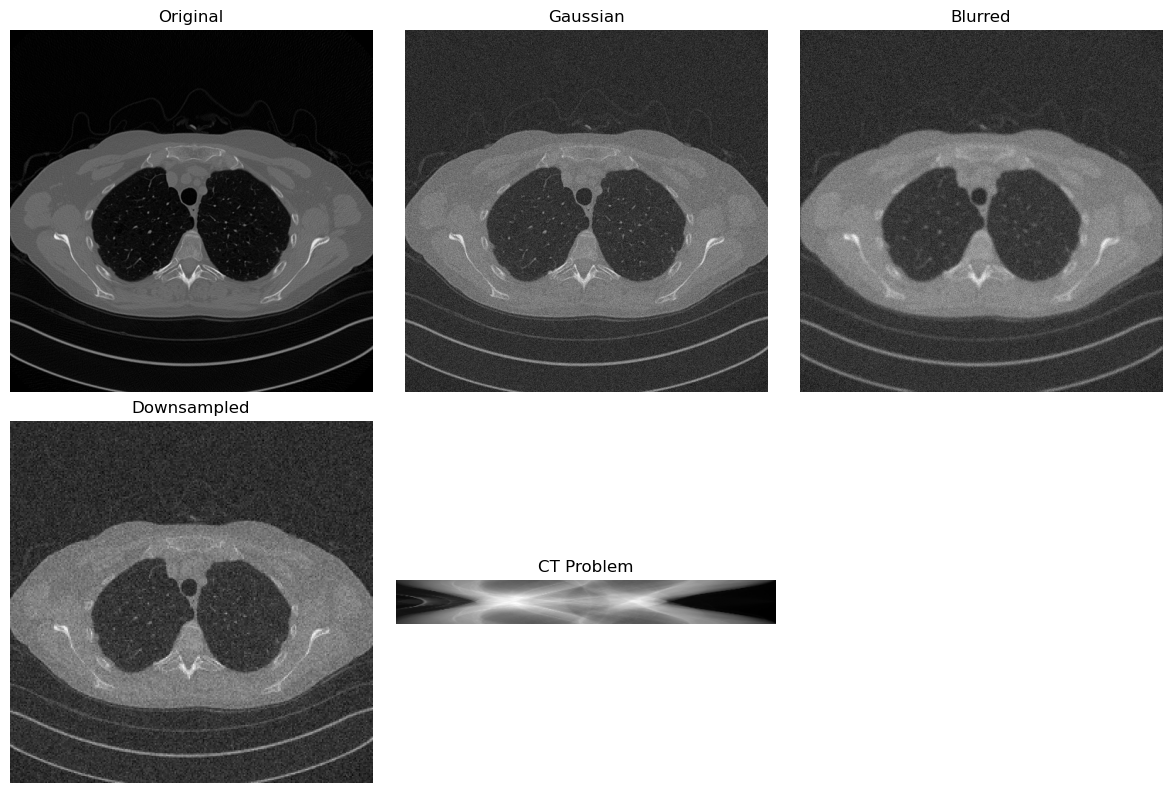

In [5]:
# Display the results

plt.figure(figsize=(12, 8))

titles = ["Original",
          "Gaussian",
          "Blurred",
          "Downsampled",
          "CT Problem"]

images = [x_true, y_delta_ns, y_delta_bl, y_delta_sr, y_delta_ct]

for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

---
## Solver Set-up 
Seting up solver as a model-based regularization method by using the regularization functions as:
- Tikhonov
- Total Variation (TV)
- Total-p Variation (TpV)

Denoised
(00:00:00) Iteration 1/100 -> RE: 0.2215, SSIM: 0.4507.
dict_keys(['residues', 'RE', 'RMSE', 'PSNR', 'SSIM', 'iterations'])
PSNR: 26.05 dB | SSIM: 0.4507 | RE: 0.2215
(00:00:00) Iteration 1/200 -> RE: 0.8828, SSIM: 0.3034.
(00:00:00) Iteration 2/200 -> RE: 0.6781, SSIM: 0.5490.
(00:00:00) Iteration 3/200 -> RE: 0.4245, SSIM: 0.6762.
(00:00:00) Iteration 4/200 -> RE: 0.1905, SSIM: 0.6433.
(00:00:00) Iteration 5/200 -> RE: 0.2204, SSIM: 0.5373.
(00:00:00) Iteration 6/200 -> RE: 0.4100, SSIM: 0.4395.
(00:00:00) Iteration 7/200 -> RE: 0.5587, SSIM: 0.3728.
(00:00:00) Iteration 8/200 -> RE: 0.6369, SSIM: 0.3357.
(00:00:00) Iteration 9/200 -> RE: 0.6417, SSIM: 0.3223.
(00:00:00) Iteration 10/200 -> RE: 0.5820, SSIM: 0.3284.
(00:00:00) Iteration 11/200 -> RE: 0.4752, SSIM: 0.3514.
(00:00:00) Iteration 12/200 -> RE: 0.3477, SSIM: 0.3888.
(00:00:00) Iteration 13/200 -> RE: 0.2395, SSIM: 0.4368.
(00:00:00) Iteration 14/200 -> RE: 0.2099, SSIM: 0.4892.
(00:00:00) Iteration 15/200 -> RE: 

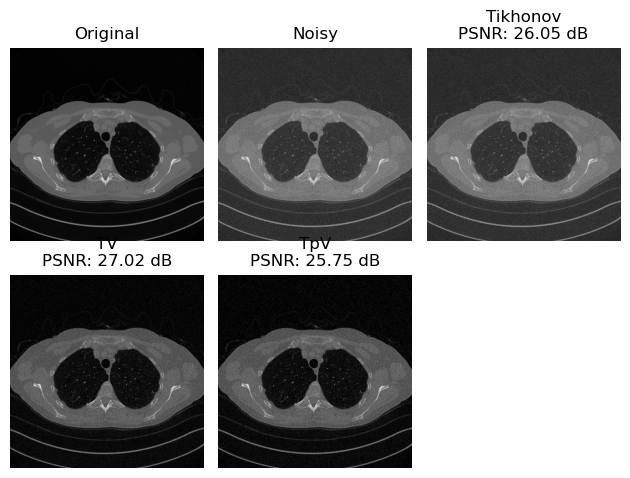

Deblurred
(00:00:00) Iteration 1/100 -> RE: 0.1721, SSIM: 0.7087.
(00:00:00) Iteration 2/100 -> RE: 0.1557, SSIM: 0.6258.
(00:00:00) Iteration 3/100 -> RE: 0.1770, SSIM: 0.5191.
(00:00:00) Iteration 4/100 -> RE: 0.2178, SSIM: 0.4160.
(00:00:00) Iteration 5/100 -> RE: 0.2689, SSIM: 0.3355.
(00:00:00) Iteration 6/100 -> RE: 0.3253, SSIM: 0.2730.
(00:00:00) Iteration 7/100 -> RE: 0.3821, SSIM: 0.2290.
(00:00:00) Iteration 8/100 -> RE: 0.4419, SSIM: 0.1940.
(00:00:00) Iteration 9/100 -> RE: 0.4983, SSIM: 0.1691.
(00:00:00) Iteration 10/100 -> RE: 0.5595, SSIM: 0.1473.
(00:00:00) Iteration 11/100 -> RE: 0.6171, SSIM: 0.1312.
(00:00:00) Iteration 12/100 -> RE: 0.6785, SSIM: 0.1165.
(00:00:00) Iteration 13/100 -> RE: 0.7372, SSIM: 0.1052.
(00:00:00) Iteration 14/100 -> RE: 0.7959, SSIM: 0.0954.
(00:00:00) Iteration 15/100 -> RE: 0.8568, SSIM: 0.0867.
(00:00:00) Iteration 16/100 -> RE: 0.9171, SSIM: 0.0790.
(00:00:00) Iteration 17/100 -> RE: 0.9773, SSIM: 0.0727.
(00:00:00) Iteration 18/100 ->

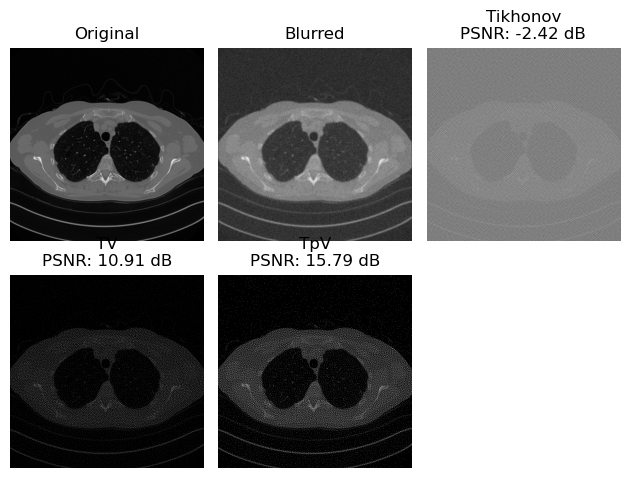

Super Resolution
(00:00:00) Iteration 1/100 -> RE: 0.2477, SSIM: 0.3693.
(00:00:00) Iteration 2/100 -> RE: 0.2478, SSIM: 0.3693.
dict_keys(['residues', 'RE', 'RMSE', 'PSNR', 'SSIM', 'iterations'])
PSNR: 25.08 dB | SSIM: 0.3693 | RE: 0.2478
(00:00:00) Iteration 1/200 -> RE: 0.9674, SSIM: 0.1718.
(00:00:00) Iteration 2/200 -> RE: 0.9046, SSIM: 0.2648.
(00:00:00) Iteration 3/200 -> RE: 0.8149, SSIM: 0.3810.
(00:00:00) Iteration 4/200 -> RE: 0.7030, SSIM: 0.4890.
(00:00:00) Iteration 5/200 -> RE: 0.5742, SSIM: 0.5635.
(00:00:00) Iteration 6/200 -> RE: 0.4361, SSIM: 0.5942.
(00:00:00) Iteration 7/200 -> RE: 0.3016, SSIM: 0.5839.
(00:00:00) Iteration 8/200 -> RE: 0.2038, SSIM: 0.5453.
(00:00:00) Iteration 9/200 -> RE: 0.2105, SSIM: 0.4933.
(00:00:00) Iteration 10/200 -> RE: 0.3082, SSIM: 0.4395.
(00:00:00) Iteration 11/200 -> RE: 0.4283, SSIM: 0.3906.
(00:00:00) Iteration 12/200 -> RE: 0.5435, SSIM: 0.3494.
(00:00:00) Iteration 13/200 -> RE: 0.6437, SSIM: 0.3164.
(00:00:00) Iteration 14/200 

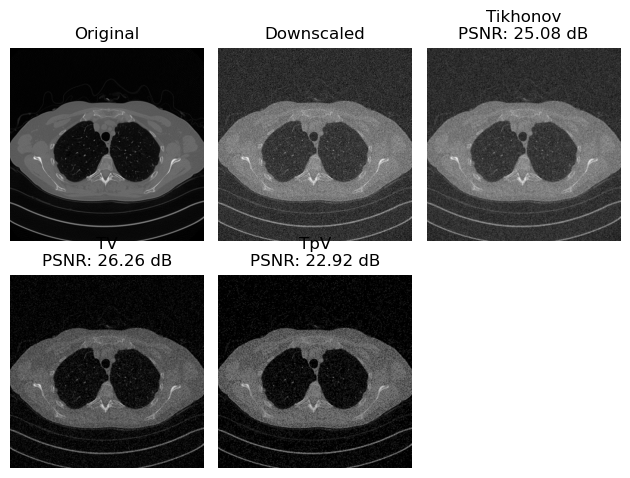

CT Reconstruction
(00:00:00) Iteration 1/100 -> RE: 0.6366, SSIM: 0.3193.
(00:00:00) Iteration 2/100 -> RE: 0.4181, SSIM: 0.3649.
(00:00:00) Iteration 3/100 -> RE: 0.3228, SSIM: 0.5061.
(00:00:00) Iteration 4/100 -> RE: 0.2791, SSIM: 0.5741.
(00:00:00) Iteration 5/100 -> RE: 0.2448, SSIM: 0.6090.
(00:00:00) Iteration 6/100 -> RE: 0.2268, SSIM: 0.6189.
(00:00:00) Iteration 7/100 -> RE: 0.2215, SSIM: 0.6197.
(00:00:00) Iteration 8/100 -> RE: 0.2154, SSIM: 0.6166.
(00:00:00) Iteration 9/100 -> RE: 0.2083, SSIM: 0.6142.
(00:00:00) Iteration 10/100 -> RE: 0.2039, SSIM: 0.6027.
(00:00:00) Iteration 11/100 -> RE: 0.2016, SSIM: 0.5989.
(00:00:00) Iteration 12/100 -> RE: 0.2001, SSIM: 0.5964.
(00:00:00) Iteration 13/100 -> RE: 0.1992, SSIM: 0.5946.
(00:00:00) Iteration 14/100 -> RE: 0.1987, SSIM: 0.5942.
(00:00:01) Iteration 15/100 -> RE: 0.1986, SSIM: 0.5946.
(00:00:01) Iteration 16/100 -> RE: 0.1982, SSIM: 0.5950.
(00:00:01) Iteration 17/100 -> RE: 0.1981, SSIM: 0.5958.
(00:00:01) Iteration 1

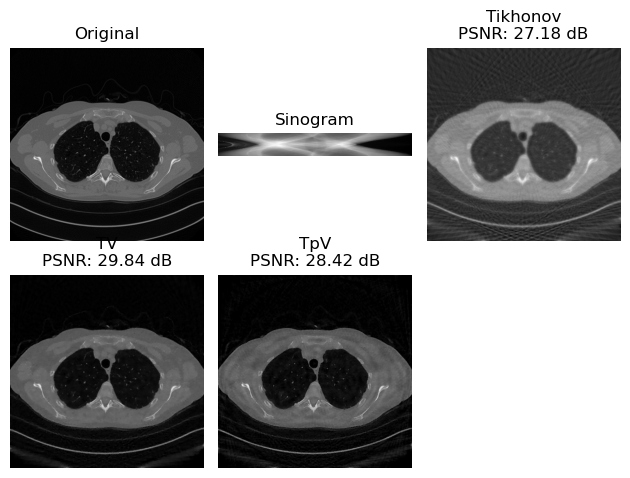

In [6]:
from IPPy.utilities import save_image
from IPPy.utilities.metrics import PSNR, SSIM, RE
from IPPy import solvers

# Setting up the list of operators
K_operators = [K_ns, K_bl, K_sp, K_ct]
y_deltas = [y_delta_ns, y_delta_bl, y_delta_sr, y_delta_ct]

solver_titles = ["Denoised",
                 "Deblurred",
                 "Super Resolution",
                 "CT Reconstruction"]

for i, operator in enumerate(K_operators):
    # for each each operators the problem is solved with each model-based regularizion method cited before
    print(solver_titles[i])

    # Set up the solver: Tikhonov
    lambda_tik=0.1
    maxiter=100
    tolf=tolx=1.e-7
    solver = solvers.CGLS(operator)

    x_sol_tik, info = solver(
        y_deltas[i],
        x_true=x_true,
        starting_point=torch.zeros_like(x_true),
        lam=lambda_tik,
        maxiter=maxiter,
        tolf=tolf,
        tolx=tolx,
        verbose=True,
    )
    print(info.keys())

    # Compute metrics
    psnr_tik = float(PSNR(x_sol_tik, x_true))
    ssim_tik = float(SSIM(x_sol_tik, x_true))
    re_tik = float(RE(x_sol_tik, x_true))
    print(f"PSNR: {psnr_tik:.2f} dB | SSIM: {ssim_tik:.4f} | RE: {re_tik:.4f}")
        
    # Set up the solver: TV
    lambda_tv = 5e-4
    maxiter = 200
    tolf = tolx = 1e-6
    solver = solvers.ChambollePockTpVUnconstrained(operator)

    # Run the solver
    x_sol_tv, info = solver(
        y_deltas[i],
        x_true=x_true,
        starting_point=torch.zeros_like(x_true),
        lmbda=lambda_tv,
        maxiter=maxiter,
        tolf=tolf,
        tolx=tolx,
        p=1.0,
        verbose=True,
    )

    # Compute metrics
    psnr_tv = float(PSNR(x_sol_tv, x_true))
    ssim_tv = float(SSIM(x_sol_tv, x_true))
    re_tv = float(RE(x_sol_tv, x_true))
    print(f"Solver: {solver_titles[i]} - PSNR: {psnr_tv:.2f} dB | SSIM: {ssim_tv:.4f} | RE: {re_tv:.4f}")

    # Save the results
    #save_image(normalize(x_sol), "denoised_imageTV.png")

    # Set up the solver: TpV (with p = 0.5)
    lambda_tv = 1e-2
    maxiter_tpv = 100
    solver = solvers.ChambollePockTpVUnconstrained(operator)

    # Run the solver
    x_sol_tpv, info = solver(
        y_deltas[i],
        x_true=x_true,
        starting_point=torch.ones_like(x_true),
        lmbda=lambda_tv,
        maxiter=maxiter_tpv,
        p=0.5,
        verbose=True,
    )

    # Compute metrics
    psnr_tpv = float(PSNR(x_sol_tpv, x_true))
    ssim_tpv = float(SSIM(x_sol_tpv, x_true))
    re_tpv = float(RE(x_sol_tpv, x_true))
    print(f"Solver: {solver_titles[i]} - PSNR: {psnr_tpv:.2f} dB | SSIM: {ssim_tpv:.4f} | RE: {re_tpv:.4f}")

    degraded_titles = ["Noisy", "Blurred", "Downscaled", "Sinogram"]
    x_sol_images = [x_true, y_deltas[i], x_sol_tik, x_sol_tv, x_sol_tpv]
    titles = ["Original", degraded_titles[i], f"Tikhonov\nPSNR: {psnr_tik:.2f} dB", f"TV\nPSNR: {psnr_tv:.2f} dB", f"TpV\nPSNR: {psnr_tpv:.2f} dB"]

    for j in range(5):
        plt.subplot(2, 3, j+1)
        plt.imshow(x_sol_images[j].detach().cpu().squeeze().numpy(), cmap="gray")
        plt.title(titles[j])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPPy import solvers
from IPPy.utilities.metrics import PSNR, SSIM, RE

# Define lambdas to test for TV and TpV
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]

def evaluate_solvers(K, y_delta, x_true, task_name="Task"):
    print(f"--- Evaluating {task_name} ---")
    results = {'Tikhonov_CGLS': {'psnr': [], 'ssim': [], 're': [], 'imgs': []},
               'TV': {'psnr': [], 'ssim': [], 're': [], 'imgs': []},
               'TpV': {'psnr': [], 'ssim': [], 're': [], 'imgs': []}}
    
    x0 = torch.zeros_like(x_true)
    
    # --- 1. Iterative Regularization (CGLS) ---
    # Run once for 50 iterations. The iterations act as the regularization parameter.
    solver_tik = solvers.CGLS(K)
    x_tik, info_tik = solver_tik(y_delta, x_true=x_true, starting_point=x0, maxiter=50, tolx=1e-5, tolf=1e-5, verbose=False)
    
    # Extract the metrics across iterations
    # info['PSNR'] is a tensor of shape (iters, 1). We detach and convert to list of floats.
    results['Tikhonov_CGLS']['psnr'] = info_tik['PSNR'].detach().cpu().numpy().flatten().tolist()
    results['Tikhonov_CGLS']['ssim'] = info_tik['SSIM'].detach().cpu().numpy().flatten().tolist()
    results['Tikhonov_CGLS']['re'] = info_tik['RE'].detach().cpu().numpy().flatten().tolist()
    
    # We will pick the best reconstruction iteration later, but let's just save the final image. 
    # (To get the image at the best iteration, we'd theoretically need to save them all, but CGLS only returns the final.
    # For now, we will store the final x_tik to avoid re-running CGLS step-by-step).
    results['Tikhonov_CGLS']['imgs'].append(x_tik)
    results['Tikhonov_CGLS']['best_iter'] = np.argmax(results['Tikhonov_CGLS']['psnr'])
    
    # --- 2. TV and TpV (Lambda sweep) ---
    for lmbda in lambdas:
        # TV (p=1.0)
        solver_tv = solvers.ChambollePockTpVUnconstrained(K)
        x_tv, _ = solver_tv(y_delta, x_true=x_true, starting_point=x0, lmbda=lmbda, maxiter=50, p=1.0, tolx=1e-5, tolf=1e-5, verbose=False)
        results['TV']['psnr'].append(float(PSNR(x_tv, x_true)))
        results['TV']['ssim'].append(float(SSIM(x_tv, x_true)))
        results['TV']['re'].append(float(RE(x_tv, x_true)))
        results['TV']['imgs'].append(x_tv)
        
        # TpV (p=0.5)
        solver_tpv = solvers.ChambollePockTpVUnconstrained(K)
        x_tpv, _ = solver_tpv(y_delta, x_true=x_true, starting_point=x0, lmbda=lmbda, maxiter=50, p=0.5, tolx=1e-5, tolf=1e-5, verbose=False)
        results['TpV']['psnr'].append(float(PSNR(x_tpv, x_true)))
        results['TpV']['ssim'].append(float(SSIM(x_tpv, x_true)))
        results['TpV']['re'].append(float(RE(x_tpv, x_true)))
        results['TpV']['imgs'].append(x_tpv)
        
    return results

def plot_metrics(results, task_name):
    # Plot 1: TV and TpV vs Lambda
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{task_name} - TV and TpV Metrics vs Lambda")
    for method in ['TV', 'TpV']:
        axs[0].plot(lambdas, results[method]['psnr'], marker='o', label=method)
        axs[1].plot(lambdas, results[method]['ssim'], marker='o', label=method)
        axs[2].plot(lambdas, results[method]['re'], marker='o', label=method)
    axs[0].set_title('PSNR'); axs[0].set_xscale('log'); axs[0].set_xlabel('Lambda'); axs[0].legend()
    axs[1].set_title('SSIM'); axs[1].set_xscale('log'); axs[1].set_xlabel('Lambda'); axs[1].legend()
    axs[2].set_title('Relative Error'); axs[2].set_xscale('log'); axs[2].set_xlabel('Lambda'); axs[2].legend()
    plt.show()

    # Plot 2: CGLS vs Iterations
    iters = range(len(results['Tikhonov_CGLS']['psnr']))
    fig2, axs2 = plt.subplots(1, 3, figsize=(15, 4))
    fig2.suptitle(f"{task_name} - CGLS Metrics vs Iteration (Iterative Regularization)")
    axs2[0].plot(iters, results['Tikhonov_CGLS']['psnr'], color='green', label='CGLS')
    axs2[1].plot(iters, results['Tikhonov_CGLS']['ssim'], color='green', label='CGLS')
    axs2[2].plot(iters, results['Tikhonov_CGLS']['re'], color='green', label='CGLS')
    axs2[0].set_title('PSNR'); axs2[0].set_xlabel('Iteration'); axs2[0].legend()
    axs2[1].set_title('SSIM'); axs2[1].set_xlabel('Iteration'); axs2[1].legend()
    axs2[2].set_title('Relative Error'); axs2[2].set_xlabel('Iteration'); axs2[2].legend()
    plt.show()

def plot_best_reconstructions(results, task_name):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Best Reconstructions for {task_name} (based on PSNR)")
    
    # CGLS (Final iteration shown)
    cgls_best_psnr = max(results['Tikhonov_CGLS']['psnr'])
    cgls_best_iter = results['Tikhonov_CGLS']['best_iter']
    axs[0].imshow(results['Tikhonov_CGLS']['imgs'][-1].detach().squeeze().cpu().numpy(), cmap='gray')
    axs[0].set_title(f"CGLS (MaxIter=50)\nBest PSNR {cgls_best_psnr:.2f} dB (at iter {cgls_best_iter})")
    axs[0].axis('off')

    # TV
    tv_best_idx = np.argmax(results['TV']['psnr'])
    tv_best_lmbda = lambdas[tv_best_idx]
    axs[1].imshow(results['TV']['imgs'][tv_best_idx].detach().squeeze().cpu().numpy(), cmap='gray')
    axs[1].set_title(f"TV (lambda={tv_best_lmbda})\nPSNR: {results['TV']['psnr'][tv_best_idx]:.2f} dB")
    axs[1].axis('off')

    # TpV
    tpv_best_idx = np.argmax(results['TpV']['psnr'])
    tpv_best_lmbda = lambdas[tpv_best_idx]
    axs[2].imshow(results['TpV']['imgs'][tpv_best_idx].detach().squeeze().cpu().numpy(), cmap='gray')
    axs[2].set_title(f"TpV (lambda={tpv_best_lmbda})\nPSNR: {results['TpV']['psnr'][tpv_best_idx]:.2f} dB")
    axs[2].axis('off')

    plt.show()


## Evaluating Denoising

--- Evaluating Deblurring ---


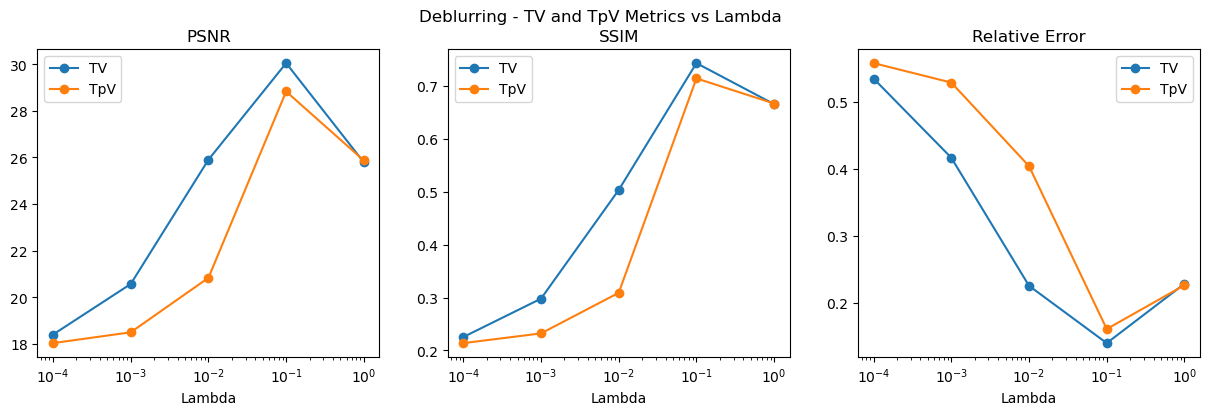

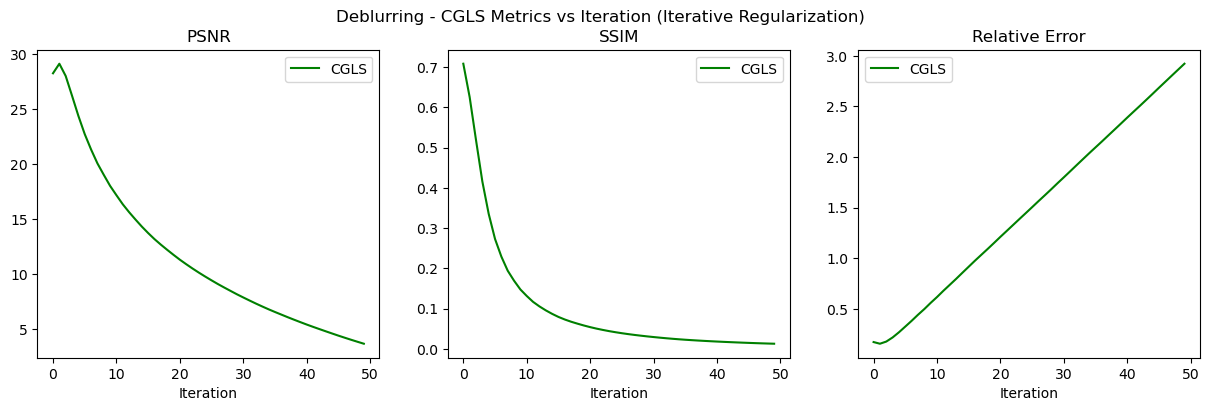

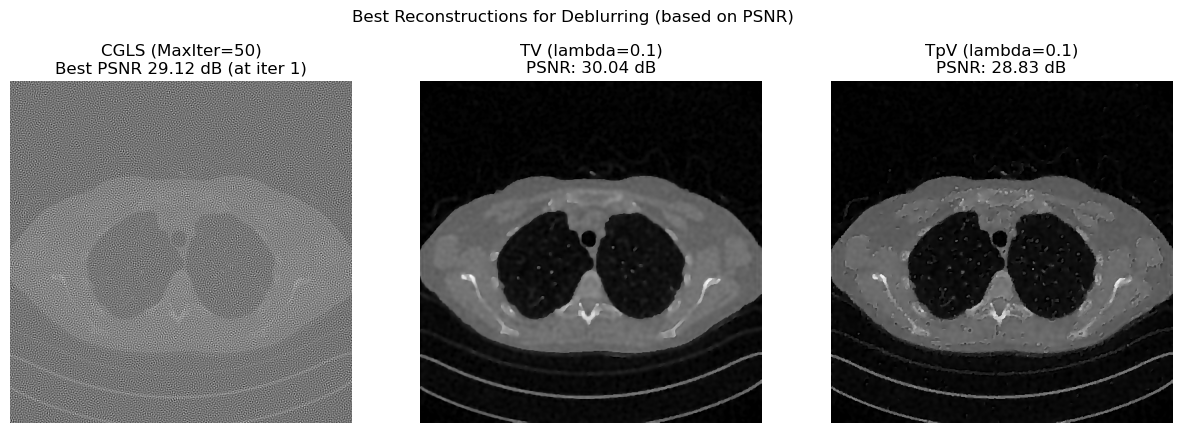

In [8]:
res_bl = evaluate_solvers(K_bl, y_delta_bl, x_true, "Deblurring")
plot_metrics(res_bl, "Deblurring")
plot_best_reconstructions(res_bl, "Deblurring")


### Deblurring Charts Analysis
- **TV & TpV vs Lambda:** Inverting a blur kernel is highly ill-posed, and doing so naturally amplifies any high-frequency noise. The peak in these charts represents the exact regularizer strength needed to suppress that noise amplification without blurring the image all over again. TpV often achieves higher peaks here because its stronger sparsity prior allows for sharper recovered edges than TV.
- **CGLS vs Iterations:** Deblurring with CGLS requires iterations to recover sharp edges. As iterations progress, the image gets sharper (PSNR increases), but eventually, the noise amplification takes over, leading to a sharp drop in PSNR. Stopping exactly at the peak is critical to get a sharp image before it becomes corrupted by amplified noise.


## Evaluating Super Resolution

--- Evaluating Super Resolution ---


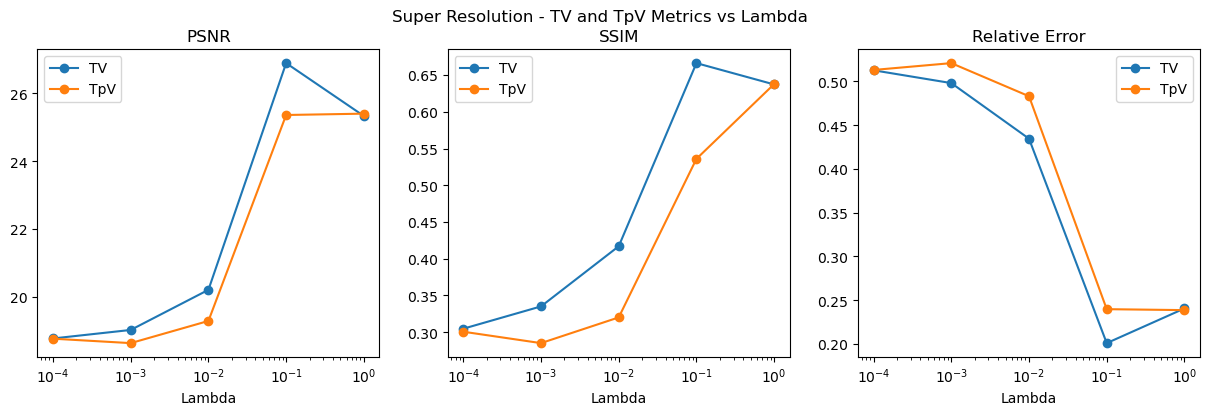

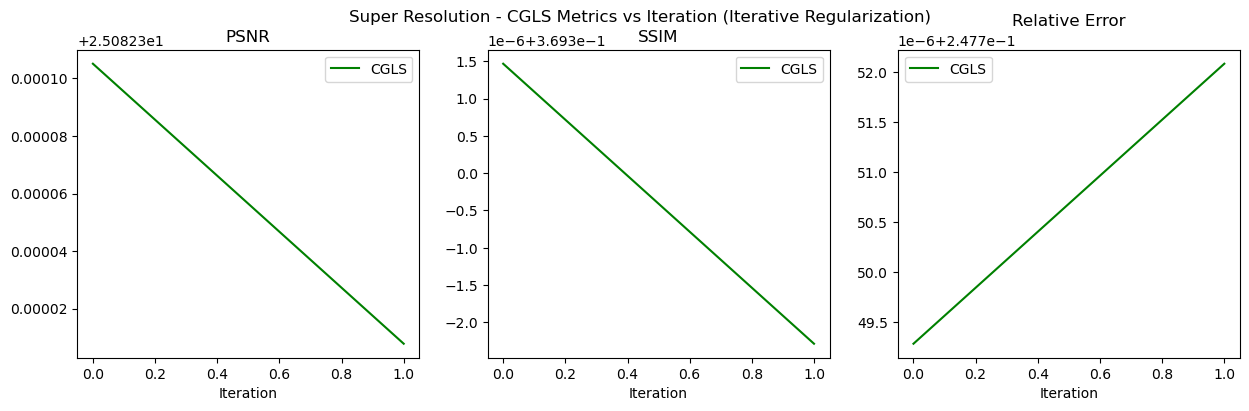

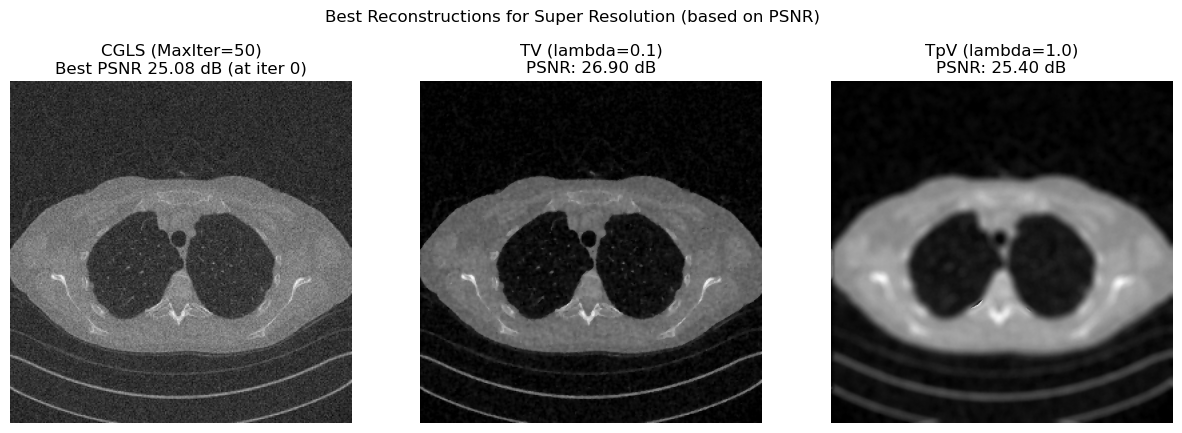

In [9]:
res_sr = evaluate_solvers(K_sp, y_delta_sr, x_true, "Super Resolution")
plot_metrics(res_sr, "Super Resolution")
plot_best_reconstructions(res_sr, "Super Resolution")


### Super Resolution Charts Analysis
- **Why CGLS is a linear/flat line:** The downscaling operator $K$ removes a massive amount of high-frequency information, creating a huge "null space" (details that are lost). Unregularized CGLS can only recover information in the row-space of $K$, meaning it just generates a blurry, upscaled version of the low-res image. Because it quickly minimizes the residual $||Kx - y||$ to near-zero *without* actually recovering any high-frequency details, the solver triggers its early-stopping tolerance (`tolf` or `tolx`) in just a couple of iterations! Thus, the plot appears as a short straight line (or completely flat) because the solver simply stops updating. It cannot invent new details without a prior.
- **TV & TpV vs Lambda:** Unlike CGLS, the TV and TpV methods use strong edge-preserving priors. They can effectively "hallucinate" or recover the lost high-frequency edges by enforcing mathematical sparsity on the image gradients. This is why their metrics peak much higher and show a beautiful response curve to `lambda`.


## Evaluating CT Reconstruction

--- Evaluating CT Reconstruction ---


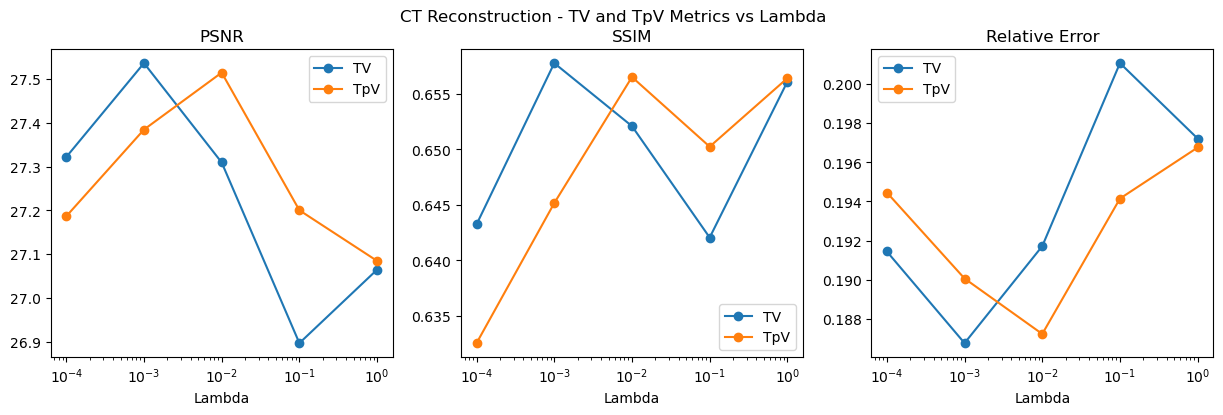

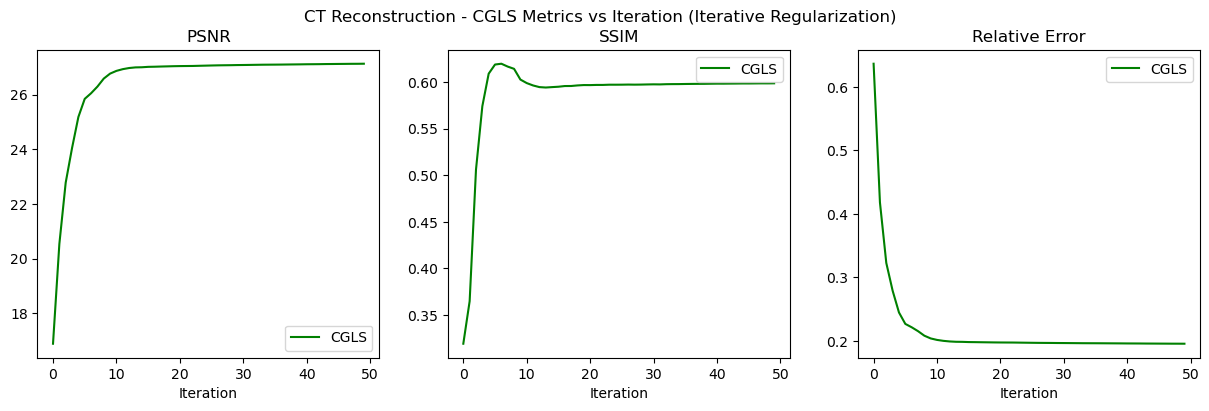

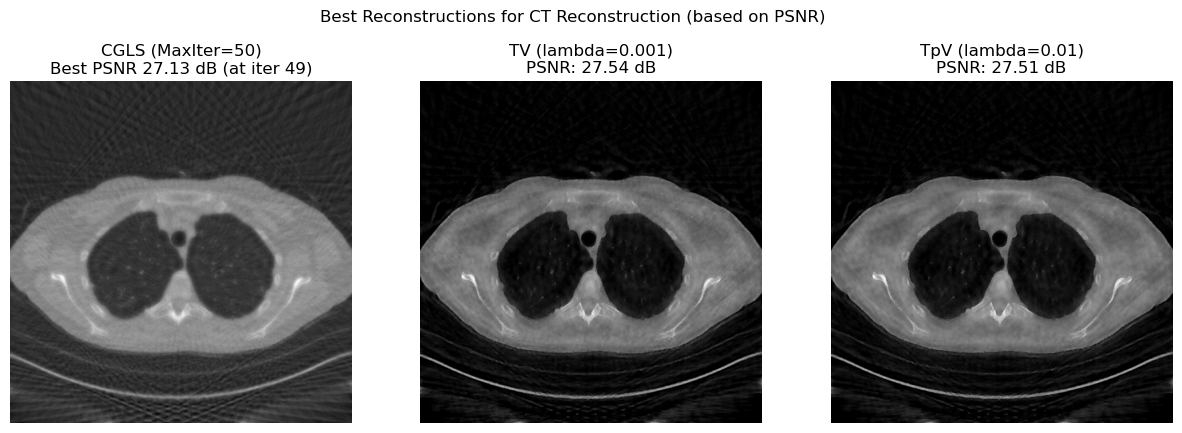

In [10]:
res_ct = evaluate_solvers(K_ct, y_delta_ct, x_true, "CT Reconstruction")
plot_metrics(res_ct, "CT Reconstruction")
plot_best_reconstructions(res_ct, "CT Reconstruction")


### CT Reconstruction Charts Analysis
- **TV & TpV vs Lambda:** CT reconstruction from limited angles or noisy projections typically suffers from streak artifacts. The optimal `lambda` effectively removes these streaks by penalizing non-sparse gradients, yielding a clean, piece-wise constant reconstruction that is ideal for medical imaging (like bones and tissues).
- **CGLS vs Iterations:** Because the noise level in this specific CT test problem was set to zero (`noise_level=0.000`), the semi-convergence degradation is much less severe. The solver steadily improves the reconstruction and maintains a high PSNR without violently overfitting to noise, eventually plateauing or stopping.


## Considerations and Discussion

**Role of Regularization Parameters:**
- **TV and TpV (Lambda):** The regularization parameter `lambda` controls the balance between data fidelity and the regularization prior (sparsity of the image gradients). 
  - **Low `lambda`:** Overfits to the noise, resulting in grainy reconstructions.
  - **High `lambda`:** Over-smooths the image, destroying textures and sharp boundaries.
  - **Optimal `lambda`:** Balances noise suppression and detail preservation. This is visible as a peak in the PSNR and SSIM curves vs `lambda`.
- **CGLS (Iterative Regularization):** In standard Conjugate Gradient Least Squares, early stopping acts as a regularizer instead of an explicit `lambda`. The number of iterations determines the trade-off.
  - **Low Iterations:** The solution is overly smooth and hasn't converged to the details.
  - **High Iterations:** The solver starts fitting the noise (semi-convergence behavior), causing the metrics (PSNR) to drop after peaking.
  - **Optimal Iteration:** The iteration where the PSNR peaks is equivalent to finding the best `lambda`. 

**Comparison of Model-Based Approaches:**
- **CGLS (Implicit L2/Tikhonov):** Since it iteratively approximates an L2 regularization, it tends to over-smooth sharp boundaries. While it handles simple denoising relatively well, it struggles to preserve sharp edges in deblurring and super-resolution.
- **Total Variation (TV - L1 of gradients):** Specifically designed to preserve edges while heavily penalizing noise. This makes it significantly superior to CGLS for natural images with sharp boundaries.
- **Total p-Variation (TpV with p=0.5):** Uses an Lp norm, enforcing an even stronger sparsity prior on the gradients. This often completely removes "staircasing" artifacts seen in standard TV and achieves the sharpest edges and the highest overall PSNR/SSIM.

Overall, explicitly injecting edge-preserving priors (TV, TpV) and properly tuning `lambda` yields much higher quality reconstructions across all four inverse problem tasks compared to iterative L2 regularization (CGLS).
